In [12]:
# セル1：ライブラリのインポート
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tkinter as tk
from tkinter import filedialog
from collections import defaultdict

print("ライブラリの読み込みが完了しました。")

ライブラリの読み込みが完了しました。


In [13]:
# セル2：メインフォルダの選択

# ダイアログ用ウィンドウを裏で作成（最前面に固定）
root = tk.Tk()
root.withdraw()
root.attributes('-topmost', True)

# フォルダ選択ダイアログを開く
main_dir = filedialog.askdirectory(title="解析対象のメインフォルダを選択してください")

if not main_dir:
    print("⚠️ フォルダ選択がキャンセルされました。次のセルには進まず、やり直してください。")
else:
    print(f"✅ 選択されたメインフォルダ:\n{main_dir}")

✅ 選択されたメインフォルダ:
E:/001_2026AI班/futabaデータ/半透明PP(J707EG)/合わせたやつ(0.5mm‗再々,1.0mm_＋再)/データフォルダ


In [14]:
# セル3：対象ファイルのリストアップ（事前確認）

if not main_dir:
    raise ValueError("メインフォルダが選択されていません。セル2を再実行してフォルダを選んでください。")

target_files = []

# os.walkでフォルダの最深部までCSVファイルを探す
for dirpath, dirnames, filenames in os.walk(main_dir):
    for f in filenames:
        if f.lower().endswith('.csv'):
            # ファイルのフルパスを作成してリストに追加
            target_files.append(os.path.join(dirpath, f))

print(f"🔍 見つかったCSVファイル: 合計 {len(target_files)} 件")

# 最初の数件だけ試しにパスを表示して確認
if target_files:
    print("\n【処理対象ファイルの例】")
    for f in target_files[:3]:
        print(" -", f)
    if len(target_files) > 3:
        print("   ... (他省略)")
else:
    print("⚠️ CSVファイルが見つかりませんでした。フォルダを確認してください。")

🔍 見つかったCSVファイル: 合計 1290 件

【処理対象ファイルの例】
 - E:/001_2026AI班/futabaデータ/半透明PP(J707EG)/合わせたやつ(0.5mm‗再々,1.0mm_＋再)/データフォルダ\0.5mm\190℃\001_190℃_020_0.5mm.csv
 - E:/001_2026AI班/futabaデータ/半透明PP(J707EG)/合わせたやつ(0.5mm‗再々,1.0mm_＋再)/データフォルダ\0.5mm\190℃\002_190℃_020_0.5mm.csv
 - E:/001_2026AI班/futabaデータ/半透明PP(J707EG)/合わせたやつ(0.5mm‗再々,1.0mm_＋再)/データフォルダ\0.5mm\190℃\003_190℃_020_0.5mm.csv
   ... (他省略)


In [15]:
# セル4：設定とファイル整理（準備）

if 'target_files' not in locals() or not target_files:
    raise ValueError("処理対象のCSVファイルがありません。セル3を再実行してファイルを確認してください。")

# ==========================================
# ⚙️ 設定：解析したい列とグラフの表示設定
# ==========================================
target_columns = ['CH03', 'CH04']

# --- X軸（Frequency [Hz]）の設定 ---
x_min = 0          # 最小値
x_max = 150        # 最大値 (ナイキスト周波数)
x_step = 10       # 目盛りの間隔

# --- Y軸（Amplitude [MPa]）の設定 ---
# ※None にするとデータに合わせて自動調整されます
y_min = -0.5          # 最小値 (基本は0)
y_max = 5.0       # 最大値 (例: 0.1 に固定したい場合は 0.1 を入力)
y_step = 0.5      # 目盛りの間隔 (例: 0.02 を入力)
# ==========================================

# --- 画像をまとめる出力フォルダの設定 ---
import os
import matplotlib.pyplot as plt
from collections import defaultdict
import numpy as np

current_dir = os.getcwd()
output_dir_name = "fft_results_per_channel" 
output_dir_path = os.path.join(current_dir, output_dir_name)
os.makedirs(output_dir_path, exist_ok=True)

# 全ファイルを「末端フォルダ」ごとにグループ化
folder_to_files = defaultdict(list)
for file_path in target_files:
    dirpath = os.path.dirname(file_path)
    folder_to_files[dirpath].append(file_path)

dt = 0.001  # サンプリング間隔 (1ms)
# カラーパレットの設定（統合版グラフで列ごとに色を変えるため）
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

print(f"✅ 準備完了。")
print(f"📁 出力先フォルダ: {output_dir_path}")
print(f"🎯 処理対象の列: {', '.join(target_columns)}")
print(f"📊 X軸設定: {x_min}〜{x_max}Hz (間隔:{x_step}Hz)")
if y_max is not None:
    print(f"📊 Y軸設定: {y_min}〜{y_max}MPa (間隔:{y_step}MPa)")
else:
    print(f"📊 Y軸設定: 自動調整")
print(f"📦 処理対象の末端フォルダ数: {len(folder_to_files)} 件\n")
print("👉 次の「セル5」を実行してください。")

✅ 準備完了。
📁 出力先フォルダ: c:\Users\0uh2j\OneDrive\Desktop\vscodeで\フーリエ変換\fft_results_per_channel
🎯 処理対象の列: CH03, CH04
📊 X軸設定: 0〜150Hz (間隔:10Hz)
📊 Y軸設定: -0.5〜5.0MPa (間隔:0.5MPa)
📦 処理対象の末端フォルダ数: 12 件

👉 次の「セル5」を実行してください。


In [16]:
# セル5：列ごとの重ね描きグラフ作成（個別版）
import pandas as pd

print("🚀 【個別版】列ごとの重ね描きグラフ作成を開始します...")
success_individual = 0
error_count = 0

for dirpath, files_in_dir in folder_to_files.items():
    last_folder_name = os.path.basename(dirpath)
    
    for col_name in target_columns:
        plt.figure(figsize=(10, 5))
        valid_files_count = 0
        
        for file_path in files_in_dir:
            try:
                df = pd.read_csv(file_path, header=2)
                df = df.drop(0).reset_index(drop=True)
                if col_name not in df.columns: continue
                    
                df[col_name] = pd.to_numeric(df[col_name], errors='coerce')
                df_clean = df.dropna(subset=[col_name])
                N = len(df_clean)
                if N == 0: continue

                y = df_clean[col_name].values
                F = np.fft.fft(y)
                amp = np.abs(F) / (N / 2)
                amp[0] /= 2
                freq = np.fft.fftfreq(N, d=dt)
                
                mask = (freq >= 0)
                plt.plot(freq[mask], amp[mask], alpha=0.5, linewidth=1.0)
                valid_files_count += 1
                
            except Exception as e:
                error_count += 1
                
        if valid_files_count > 0:
            plt.xlabel('Frequency [Hz]')
            plt.ylabel('Amplitude [MPa]')
            plt.title(f'FFT Spectrum - {last_folder_name} [{col_name}] (Overlaid {valid_files_count} files)')
            
            # --- 軸の範囲と目盛り設定の適用 ---
            plt.xlim(x_min, x_max)
            plt.xticks(np.arange(x_min, x_max + x_step, x_step))
            
            if y_max is not None:
                plt.ylim(y_min, y_max)
            if y_step is not None and y_max is not None:
                plt.yticks(np.arange(y_min, y_max + y_step, y_step))
            # ----------------------------------
            
            plt.grid(True, linestyle='--', alpha=0.6)
            plt.tight_layout()
            
            output_image_name = f"{last_folder_name}_{col_name}_combined_fft.png"
            plt.savefig(os.path.join(output_dir_path, output_image_name), dpi=150)
            success_individual += 1
            print(f"  --> ✅ 保存: {output_image_name}")
            
        plt.close()

print("-" * 30)
print(f"🏁 個別グラフ完了！（生成: {success_individual}枚, エラー: {error_count}件）")
print("👉 次の「セル6」を実行してください。")

🚀 【個別版】列ごとの重ね描きグラフ作成を開始します...
  --> ✅ 保存: 190℃_CH03_combined_fft.png
  --> ✅ 保存: 190℃_CH04_combined_fft.png
  --> ✅ 保存: 210℃_CH03_combined_fft.png
  --> ✅ 保存: 210℃_CH04_combined_fft.png
  --> ✅ 保存: 230℃_CH03_combined_fft.png
  --> ✅ 保存: 230℃_CH04_combined_fft.png
  --> ✅ 保存: 190℃_CH03_combined_fft.png
  --> ✅ 保存: 190℃_CH04_combined_fft.png
  --> ✅ 保存: 210℃_CH03_combined_fft.png
  --> ✅ 保存: 210℃_CH04_combined_fft.png
  --> ✅ 保存: 230℃_CH03_combined_fft.png
  --> ✅ 保存: 230℃_CH04_combined_fft.png
  --> ✅ 保存: 190℃_CH03_combined_fft.png
  --> ✅ 保存: 190℃_CH04_combined_fft.png
  --> ✅ 保存: 210℃_CH03_combined_fft.png
  --> ✅ 保存: 210℃_CH04_combined_fft.png
  --> ✅ 保存: 230℃_CH03_combined_fft.png
  --> ✅ 保存: 230℃_CH04_combined_fft.png
  --> ✅ 保存: 190℃_CH03_combined_fft.png
  --> ✅ 保存: 190℃_CH04_combined_fft.png
  --> ✅ 保存: 210℃_CH03_combined_fft.png
  --> ✅ 保存: 210℃_CH04_combined_fft.png
  --> ✅ 保存: 230℃_CH03_combined_fft.png
  --> ✅ 保存: 230℃_CH04_combined_fft.png
------------------------------
🏁 個

In [ ]:
# セル5-2：エラー原因の特定（診断ツール）
import pandas as pd
import numpy as np
import os

# --- エラー発生状況の事前チェック ---
# セル5でカウントした error_count が存在し、かつ 0 の場合はスキップ
if 'error_count' in locals() and error_count == 0:
    print("✅ セル5でのエラー発生は 0 件でした。")
    print("👉 診断をスキップします。次のセルへ進んでください。")
else:
    print("🔍 エラーが発生したファイルの特定を開始します...\n")
    error_details = []

    # セル4で作成した folder_to_files を使って再確認
    for dirpath, files_in_dir in folder_to_files.items():
        for file_path in files_in_dir:
            csv_file = os.path.basename(file_path)
            
            for col_name in target_columns:
                try:
                    # 1. 読み込みのテスト
                    df = pd.read_csv(file_path, header=2)
                    
                    # 行数が足りない（空っぽなど）場合のチェック
                    if len(df) <= 1:
                        error_details.append(f"⚠️ [データ不足] {csv_file}: データ行が存在しません。")
                        break # このファイルは他の列のチェックも不要なので次のファイルへ
                    
                    df = df.drop(0).reset_index(drop=True)
                    
                    # 2. 列の存在チェック
                    if col_name not in df.columns:
                        error_details.append(f"⚠️ [列欠落] {csv_file}: 列 '{col_name}' が存在しません。")
                        continue
                        
                    # 3. 数値変換と欠損値のチェック
                    # 診断のため、あえてエラーを隠さない設定(errors='raise')でテストしてみます
                    try:
                        df[col_name] = pd.to_numeric(df[col_name], errors='raise')
                    except Exception as num_e:
                        error_details.append(f"❌ [数値変換エラー] {csv_file} ({col_name}): 文字列など数値にできないデータが含まれています。詳細 -> {num_e}")
                        continue
                    
                    df_clean = df.dropna(subset=[col_name])
                    N = len(df_clean)
                    
                    if N == 0:
                        error_details.append(f"⚠️ [有効データなし] {csv_file} ({col_name}): すべてのデータが欠損値(NaN)です。")
                        continue

                    # 4. FFT計算のテスト
                    y = df_clean[col_name].values
                    F = np.fft.fft(y)
                    amp = np.abs(F) / (N / 2)
                    
                except pd.errors.ParserError as e:
                    error_details.append(f"❌ [ファイル破損/書式エラー] {csv_file}: CSVの形が崩れています。詳細 -> {e}")
                    break
                except UnicodeDecodeError as e:
                    error_details.append(f"❌ [文字コードエラー] {csv_file}: UTF-8で読み込めません。詳細 -> {e}")
                    break
                except Exception as e:
                    error_details.append(f"❌ [予期せぬエラー] {csv_file} ({col_name}): {type(e).__name__} -> {e}")

    # 重複してエラーが登録されないように整理して出力
    unique_errors = list(set(error_details))
    unique_errors.sort()

    if not unique_errors:
        print("✅ 再診断の結果、プログラム上で再現するエラーは見つかりませんでした。")
        print("（一時的なメモリ不足等でセル5がエラーをカウントした可能性があります）")
    else:
        print(f"🚨 【診断結果】 {len(unique_errors)} 件の問題が特定されました:\n")
        for detail in unique_errors:
            print(detail)

    print("\n" + "-" * 50)
    print("👉 上記の結果をもとに、該当のCSVファイルの中身を直接（Excel等で）確認してみてください。")

🔍 エラーが発生したファイルの特定を開始します...

✅ 再診断の結果、プログラム上で再現するエラーは見つかりませんでした。
（一時的なメモリ不足等でセル5がエラーをカウントした可能性があります）

--------------------------------------------------
👉 上記の結果をもとに、該当のCSVファイルの中身を直接（Excel等で）確認してみてください。


🚀 【統合版】全指定列のグラフ作成を開始します...
  --> 🌟 保存: 190℃_ALL_combined_fft.png


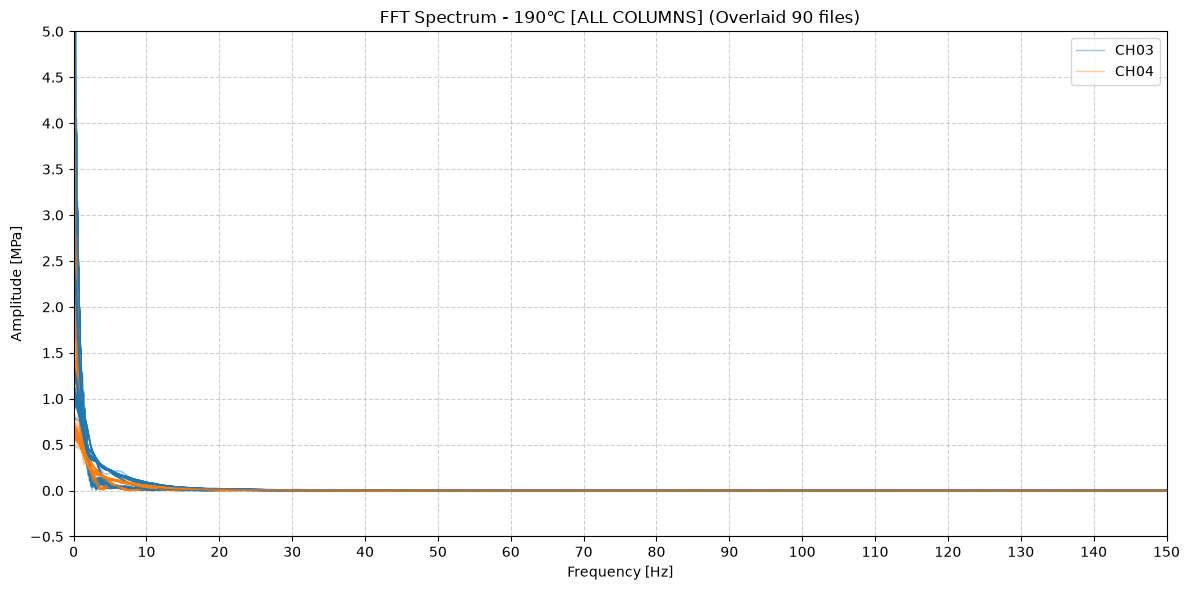

  --> 🌟 保存: 210℃_ALL_combined_fft.png


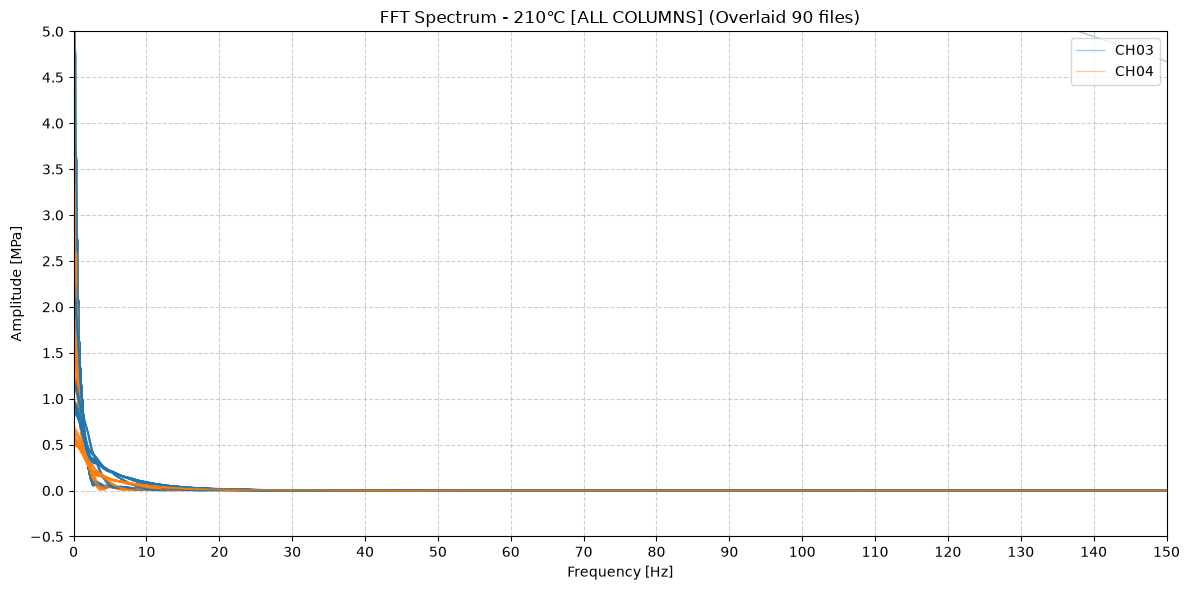

  --> 🌟 保存: 230℃_ALL_combined_fft.png


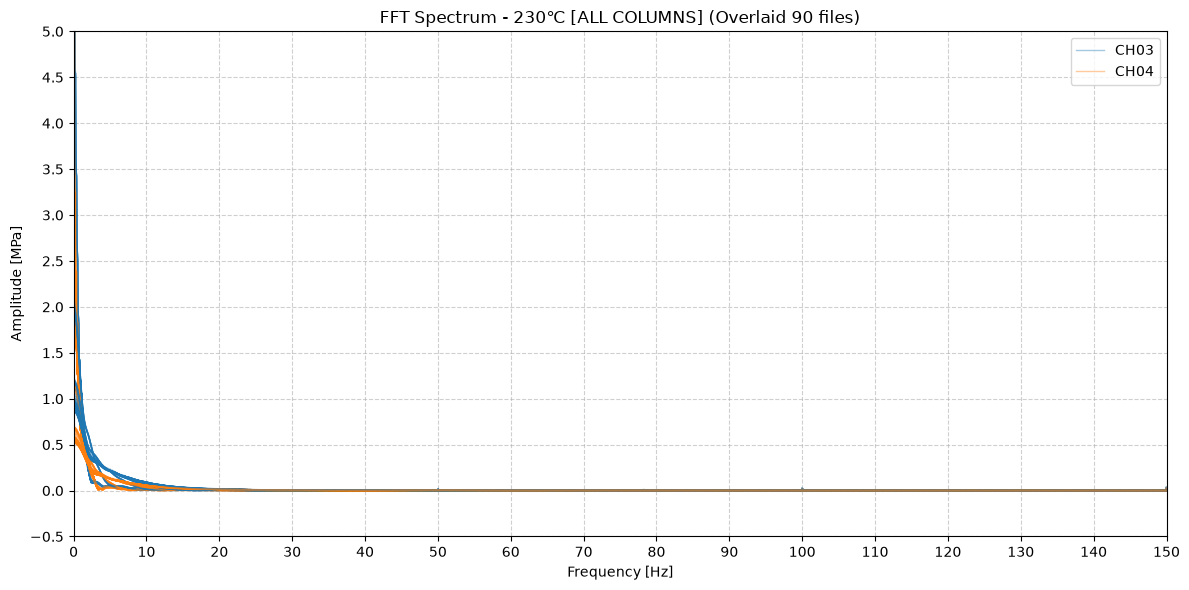

  --> 🌟 保存: 190℃_ALL_combined_fft.png


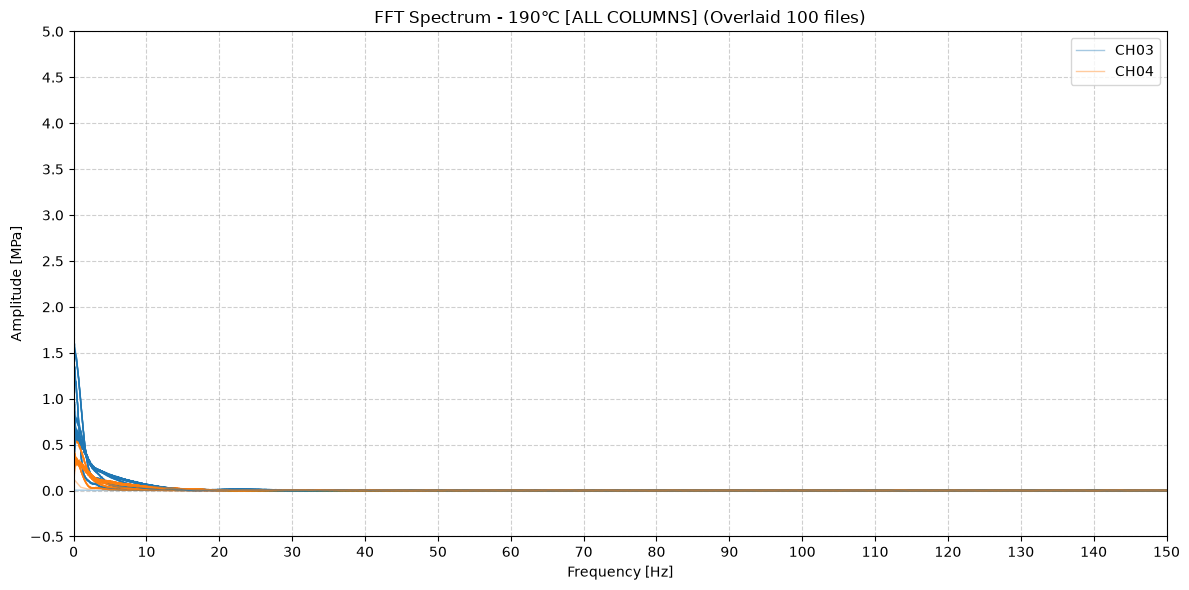

  --> 🌟 保存: 210℃_ALL_combined_fft.png


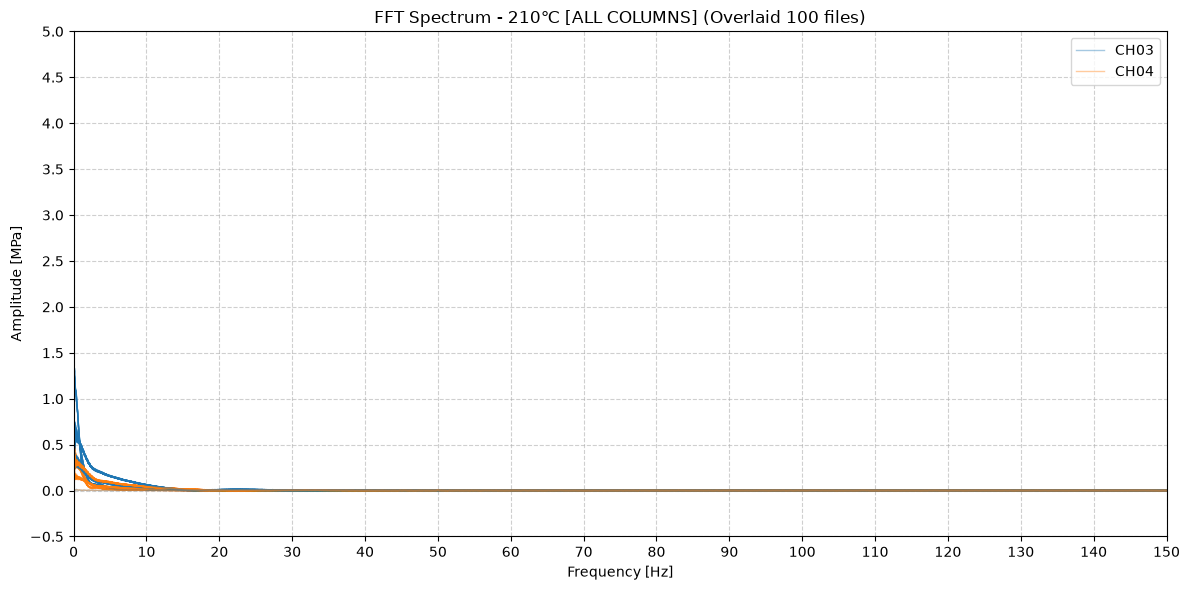

  --> 🌟 保存: 230℃_ALL_combined_fft.png


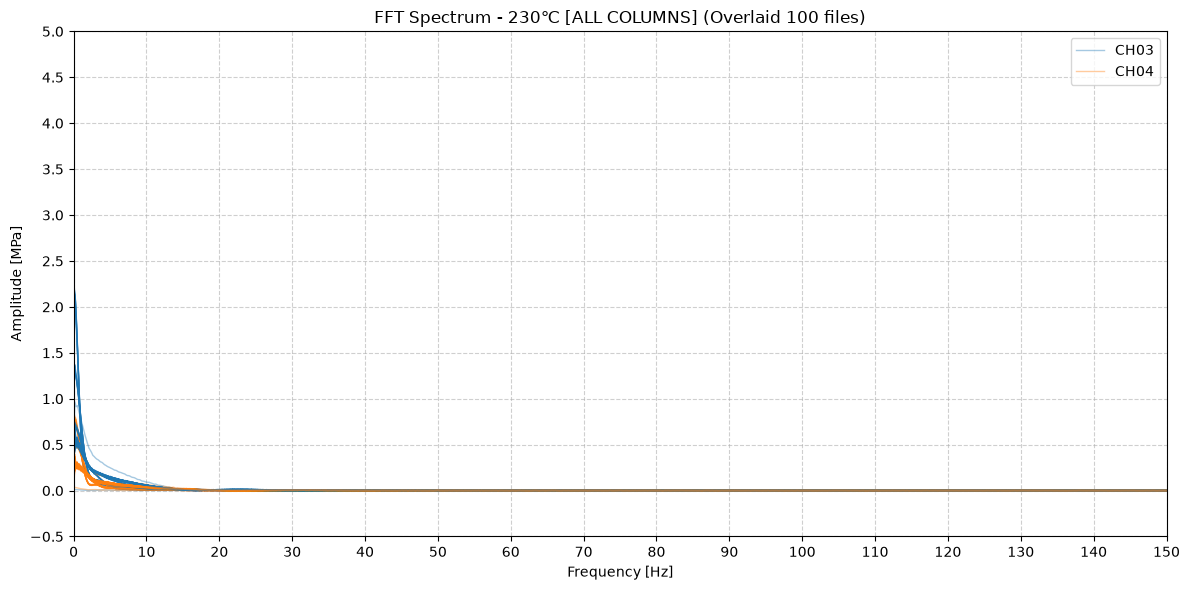

  --> 🌟 保存: 190℃_ALL_combined_fft.png


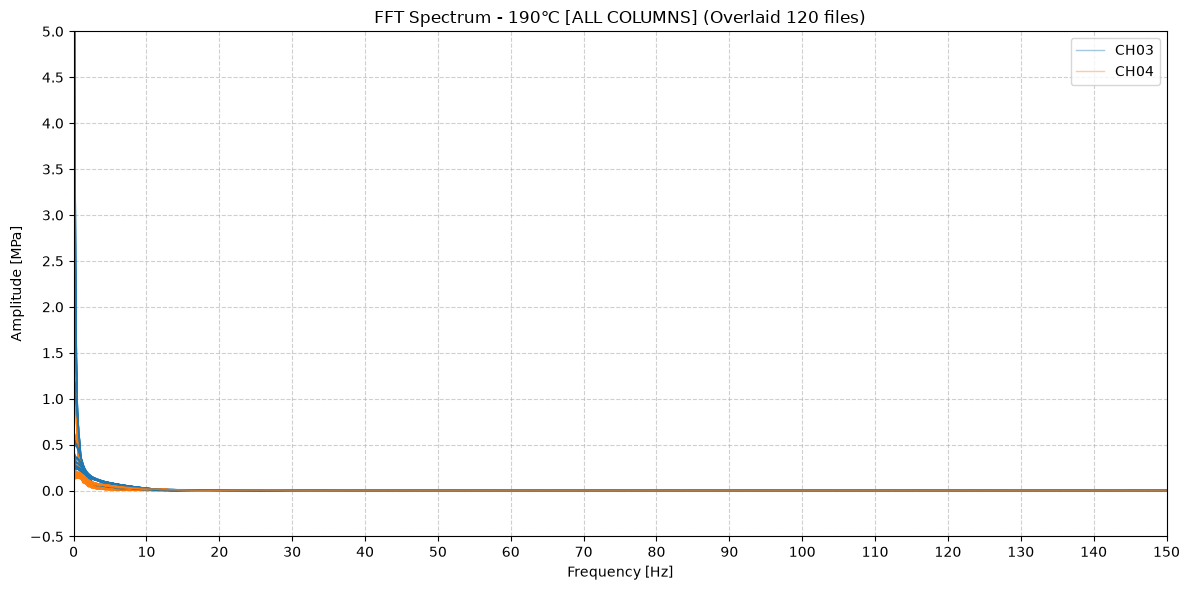

  --> 🌟 保存: 210℃_ALL_combined_fft.png


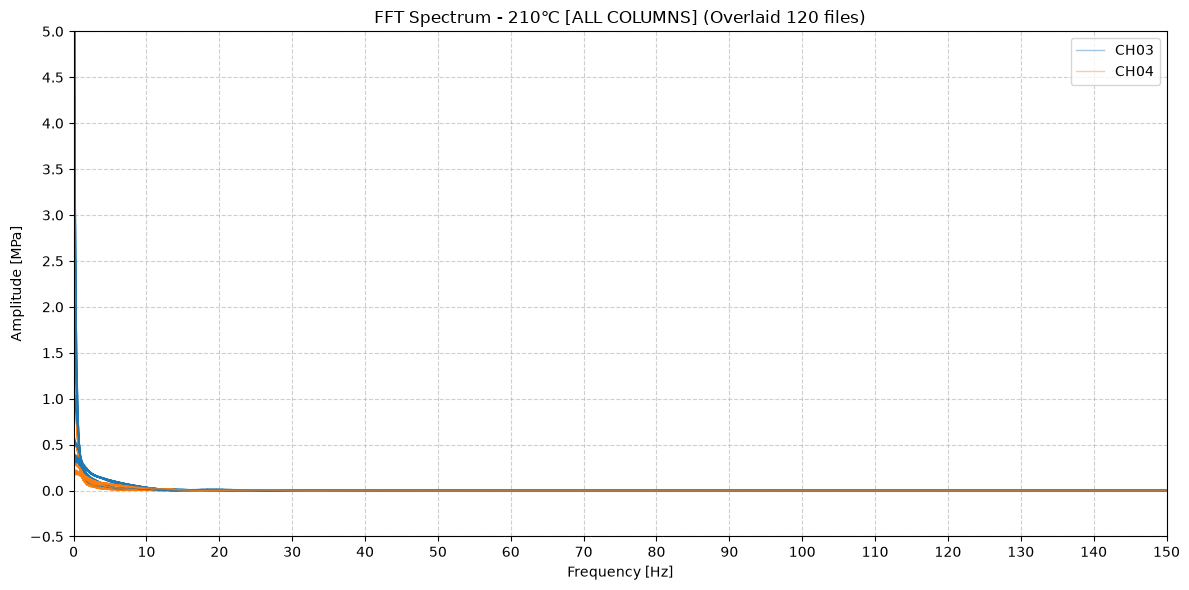

  --> 🌟 保存: 230℃_ALL_combined_fft.png


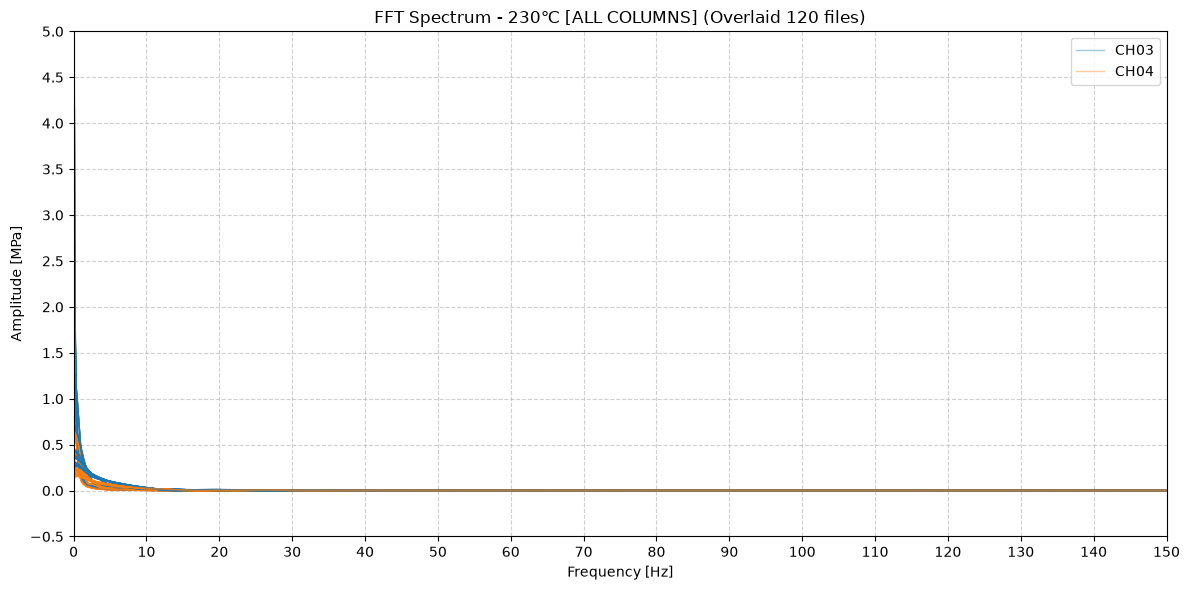

  --> 🌟 保存: 190℃_ALL_combined_fft.png


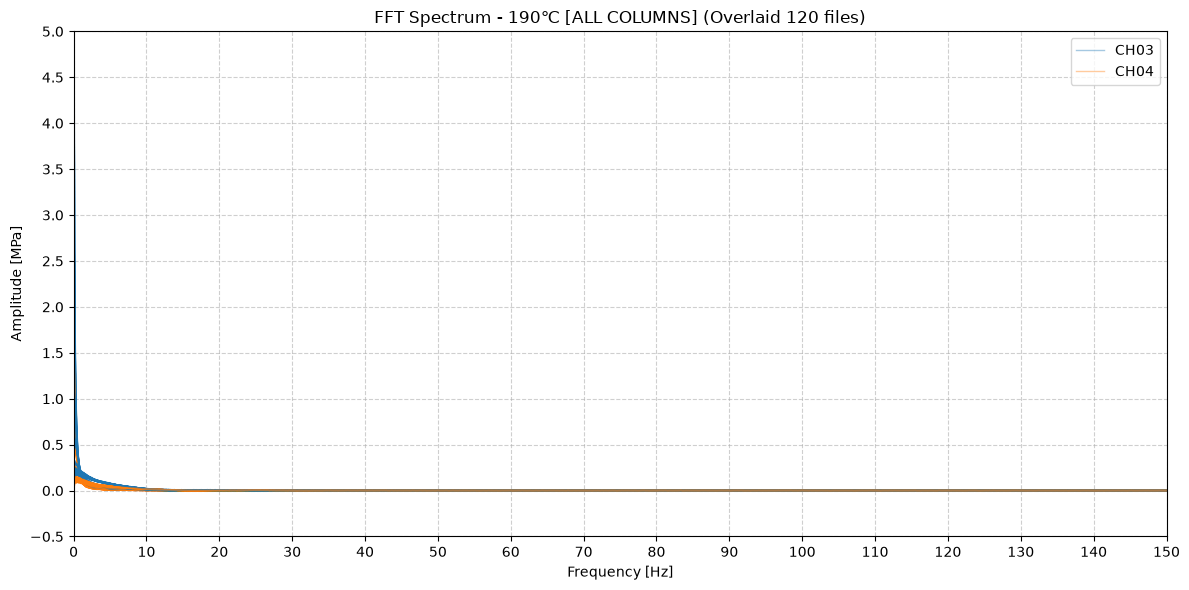

  --> 🌟 保存: 210℃_ALL_combined_fft.png


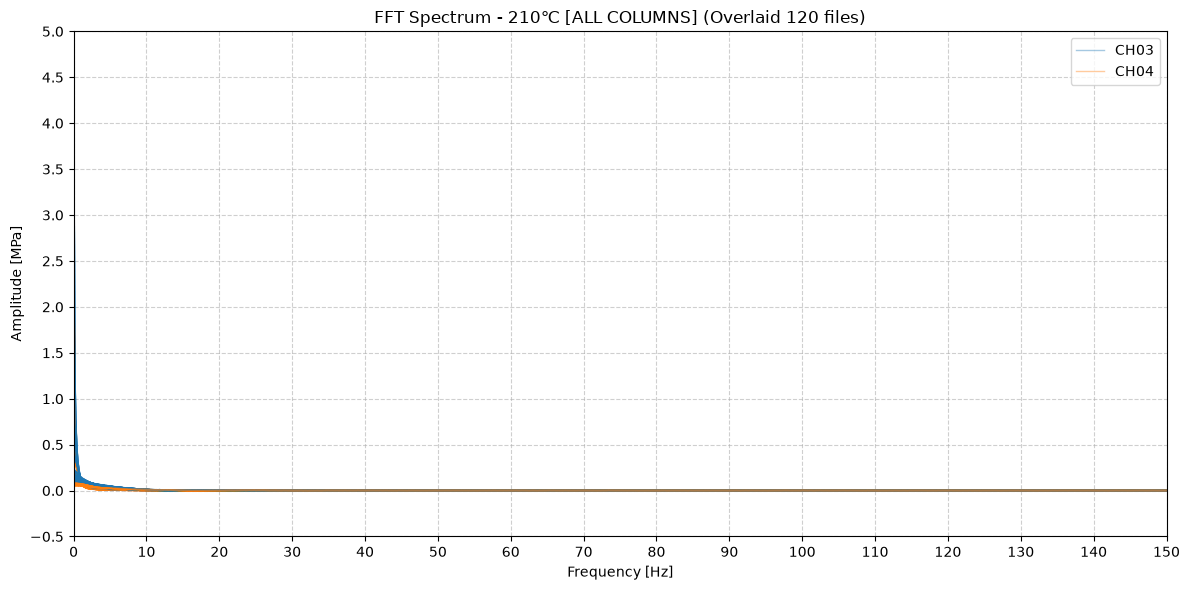

  --> 🌟 保存: 230℃_ALL_combined_fft.png


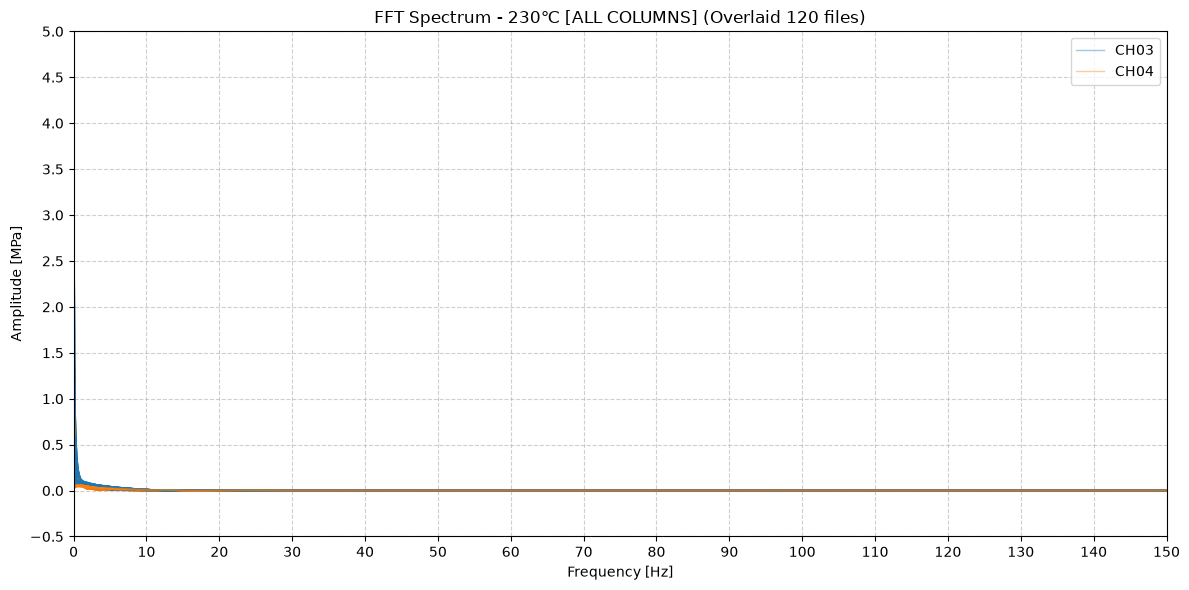

------------------------------
🏁 統合グラフ完了！（生成: 12枚）
🎉 すべての処理が正常に終了しました！出力フォルダを確認してください。


In [18]:
# セル6：全列×全ファイルの統合グラフ作成（統合版）

print("🚀 【統合版】全指定列のグラフ作成を開始します...")
success_integrated = 0

# (念のためセル4で定義されているかチェック)
if 'output_dir_path' not in locals():
    print("⚠️ 警告: セル4が実行されていない可能性があります。")

for dirpath, files_in_dir in folder_to_files.items():
    last_folder_name = os.path.basename(dirpath)
    
    plt.figure(figsize=(12, 6))
    valid_integrated_count = 0
    plotted_labels = set()
    
    for file_path in files_in_dir:
        try:
            df = pd.read_csv(file_path, header=2)
            df = df.drop(0).reset_index(drop=True)
            file_plotted = False
            
            for i, col_name in enumerate(target_columns):
                if col_name not in df.columns: continue
                
                df[col_name] = pd.to_numeric(df[col_name], errors='coerce')
                df_clean = df.dropna(subset=[col_name])
                N = len(df_clean)
                if N == 0: continue

                y = df_clean[col_name].values
                F = np.fft.fft(y)
                amp = np.abs(F) / (N / 2)
                amp[0] /= 2
                freq = np.fft.fftfreq(N, d=dt)
                mask = (freq >= 0)
                
                # 凡例の重複防止
                label_name = col_name if col_name not in plotted_labels else ""
                
                plt.plot(freq[mask], amp[mask], color=colors[i % len(colors)], 
                         alpha=0.4, linewidth=1.0, label=label_name)
                
                if label_name:
                    plotted_labels.add(col_name)
                    
                file_plotted = True
                
            if file_plotted:
                valid_integrated_count += 1
                
        except Exception:
            pass # エラーはセル5でカウント済みのためスキップ
            
    if valid_integrated_count > 0:
        plt.xlabel('Frequency [Hz]')
        plt.ylabel('Amplitude [MPa]')
        plt.title(f'FFT Spectrum - {last_folder_name} [ALL COLUMNS] (Overlaid {valid_integrated_count} files)')
        
        # --- 軸の範囲と目盛り設定の適用 ---
        plt.xlim(x_min, x_max)
        plt.xticks(np.arange(x_min, x_max + x_step, x_step))
        
        if y_max is not None:
            plt.ylim(y_min, y_max)
        if y_step is not None and y_max is not None:
            plt.yticks(np.arange(y_min, y_max + y_step, y_step))
        # ----------------------------------
        
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend(loc='upper right')
        plt.tight_layout()
        
        # 1. フォルダへの画像保存
        output_image_name_all = f"{last_folder_name}_ALL_combined_fft.png"
        plt.savefig(os.path.join(output_dir_path, output_image_name_all), dpi=150)
        success_integrated += 1
        print(f"  --> 🌟 保存: {output_image_name_all}")
        
        # 2. Jupyter Notebookの画面上に表示
        plt.show()
        
    else:
        # 描画するものがなかった場合はメモリ解放だけ行う
        plt.close()

print("-" * 30)
print(f"🏁 統合グラフ完了！（生成: {success_integrated}枚）")
print("🎉 すべての処理が正常に終了しました！出力フォルダを確認してください。")